In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib as mpl
from matplotlib import font_manager

In [2]:
df = pd.read_csv("1.csv", sep=";")

In [3]:
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

1. ContactForce_Reference_Left_cx
2. ContactForce_Reference_Left_cy
3. ContactForce_Reference_Left_cz
4. ContactForce_Reference_Left_fx
5. ContactForce_Reference_Left_fy
6. ContactForce_Reference_Left_fz
7. ContactForce_Reference_Right_cx
8. ContactForce_Reference_Right_cy
9. ContactForce_Reference_Right_cz
10. ContactForce_Reference_Right_fx
11. ContactForce_Reference_Right_fy
12. ContactForce_Reference_Right_fz
13. CurrentState
14. Default_angularAcceleration_x
15. Default_angularAcceleration_y
16. Default_angularAcceleration_z
17. Default_angularVelocity_x
18. Default_angularVelocity_y
19. Default_angularVelocity_z
20. Default_linearAcceleration_x
21. Default_linearAcceleration_y
22. Default_linearAcceleration_z
23. Default_linearVelocity_x
24. Default_linearVelocity_y
25. Default_linearVelocity_z
26. Default_orientation_w
27. Default_orientation_x
28. Default_orientation_y
29. Default_orientation_z
30. Default_position_x
31. Default_position_y
32. Default_position_z
33. EEForceSens

# Fields

In [4]:
time = df["t"].to_numpy()

#fsm = df["FSM/CurrentState"].to_numpy()  # Contiene gli interi 0, 1, 2

# --- INTERNAL FORCES ---
internalDesiredForce =  df[["InternalForce_Desired"]].to_numpy()
internalMeasuredForce = df[["InternalForce_Measured"]].to_numpy()

# --- CURRENT STATE ---
currentstate = df[["CurrentState"]].to_numpy()

# --- OBJECT TRAFECTORY ---
ObjectPlannedTrajectory = df[["ObjectTrajectory_Desired_x", "ObjectTrajectory_Desired_y", "ObjectTrajectory_Desired_z"]].to_numpy()
ObjectRealTrajectory = df[["ObjectTrajectory_Real_x", "ObjectTrajectory_Real_y", "ObjectTrajectory_Real_z"]].to_numpy()

# --- ANGULAR VELOCITY ---
RigtArmIn_dq = df[["xarm7_2_qIn_0","xarm7_2_qIn_1","xarm7_2_qIn_2","xarm7_2_qIn_3","xarm7_2_qIn_4","xarm7_2_qIn_5","xarm7_2_qIn_6"]].to_numpy()
RigtArmOut_dq = df[["xarm7_2_qOut_0","xarm7_2_qOut_1","xarm7_2_qOut_2","xarm7_2_qOut_3","xarm7_2_qOut_4","xarm7_2_qOut_5","xarm7_2_qOut_6"]].to_numpy()

LeftArmIn_dq = df[["qIn_0","qIn_1","qIn_2","qIn_3","qIn_4","qIn_5","qIn_6"]].to_numpy()
LeftArmOut_dq = df[["qOut_0","qOut_1","qOut_2","qOut_3","qOut_4","qOut_5","qOut_6"]].to_numpy()

# --- TORQUES ---
RigtArmIn_tau = df[["xarm7_2_tauIn_0","xarm7_2_tauIn_1","xarm7_2_tauIn_2","xarm7_2_tauIn_3","xarm7_2_tauIn_4","xarm7_2_tauIn_5","xarm7_2_tauIn_6"]].to_numpy()
RigtArmOut_tau = df[["xarm7_2_tauOut_0","xarm7_2_tauOut_1","xarm7_2_tauOut_2","xarm7_2_tauOut_3","xarm7_2_tauOut_4","xarm7_2_tauOut_5","xarm7_2_tauOut_6"]].to_numpy()

LeftArmIn_tau = df[["tauIn_0","tauIn_1","tauIn_2","tauIn_3","tauIn_4","tauIn_5","tauIn_6"]].to_numpy()
LeftArmOut_tau = df[["tauOut_0","tauOut_1","tauOut_2","tauOut_3","tauOut_4","tauOut_5","tauOut_6"]].to_numpy()












# Plot Template

In [5]:
from contextlib import contextmanager
import logging
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib import font_manager

# Configurazione log essenziale per avvisare in caso di fallback del font
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("PlotTemplate")


class PlotTemplate:
    """Wrapper flessibile per Matplotlib: gestione automatica dei font,
    palette di colori armonica, legenda rapida e sintassi pulita."""

    # Palette di default armonizzata (usata nel color cycle automatico di matplotlib)
    PALETTE = [
        "#005587",  # Blu (Accent principale)
        "#E05A47",  # Rosso/Arancio
        "#2A9D8F",  # Verde ottanio
        "#E9C46A",  # Giallo dorato
        "#6A4C93",  # Viola
    ]

    BASE = "#333333"        # Testi, assi e griglie
    GRID_COLOR = "#E0E0E0"
    ZERO_LINE_COLOR = "#CCCCCC"

    def __init__(self, font_name="DejaVu Sans", font_path=None, base_font_size=16, palette=None):
        self.base_font_size = base_font_size
        self.palette = palette or self.PALETTE
        
        # Imposta il font iniziale
        self.font_name = self._resolve_font(font_name, font_path)
        self._apply_global_rc()

    def _resolve_font(self, font_name, font_path=None):
        """Verifica la disponibilità del font. Se manca, fa fallback su DejaVu Sans senza arrestarsi."""
        if font_path and Path(font_path).exists():
            try:
                font_manager.fontManager.addfont(str(font_path))
                return font_manager.FontProperties(fname=str(font_path)).get_name()
            except Exception as e:
                logger.warning(f"Impossibile caricare il font da file '{font_path}': {e}. Fallback al default.")
        
        # Controlla se il font_name è installato nel sistema
        system_fonts = {f.name.lower() for f in font_manager.fontManager.ttflist}
        if font_name.lower() in system_fonts or font_name in ["DejaVu Sans", "sans-serif", "serif", "monospace"]:
            return font_name
        
        logger.warning(f"Font '{font_name}' non trovato nel sistema. Fallback a 'DejaVu Sans'.")
        return "DejaVu Sans"

    def set_font(self, font_name, font_path=None):
        """Permette di cambiare font al volo: pt.set_font('Roboto')"""
        self.font_name = self._resolve_font(font_name, font_path)
        plt.rcParams["font.family"] = self.font_name

    def set_font_size(self, base_size):
            """Permette di cambiare la dimensione base al volo per tutti gli elementi."""
            self.base_font_size = base_size
            plt.rcParams.update({
                "font.size": base_size,
                "axes.titlesize": round(base_size * 1.15),   # Titolo del singolo grafico (+15%)
                "figure.titlesize": round(base_size * 1.3),  # Titolo generale con fig.suptitle (+30%)
                "axes.labelsize": round(base_size * 0.85),   # Etichette degli assi (xlabel, ylabel)
                "xtick.labelsize": round(base_size * 0.75),  # Numeri/valori sull'asse X
                "ytick.labelsize": round(base_size * 0.75),  # Numeri/valori sull'asse Y
                "legend.fontsize": round(base_size * 0.75),  # Testo della legenda
            })

    def _apply_global_rc(self):
        """Applica gli stili di base e la ciclicità dei colori a Matplotlib."""
        rc = {
            "font.family": self.font_name,
            "axes.prop_cycle": plt.cycler(color=self.palette),  # Colori automatici!
            "text.color": self.BASE,
            "axes.labelcolor": self.BASE,
            "xtick.color": self.BASE,
            "ytick.color": self.BASE,
            "figure.constrained_layout.use": True,
        }
        plt.rcParams.update(rc)
        self.set_font_size(self.base_font_size)

    # ---------- Core API ----------

    def create(
        self,
        xlabel="",
        ylabel="",
        title="",
        figsize=(8, 5),
        nrows=1,
        ncols=1,
        zero_lines=False,
        font_name=None,
        font_size=None,
        **subplot_kwargs
    ):
        """Crea la figura e gli assi configurati."""
        # Override temporanei di font o dimensione per questo specifico grafico
        if font_name:
            plt.rcParams["font.family"] = self._resolve_font(font_name)
        if font_size:
            self.set_font_size(font_size)

        fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, **subplot_kwargs)
        axes = ax.flatten().tolist() if nrows * ncols > 1 else [ax]

        for a in axes:
            self._format_axes(a, zero_lines=zero_lines)

        if nrows * ncols == 1:
            ax.set_xlabel(xlabel)
            ax.set_ylabel(ylabel)
            ax.set_title(title)
        elif title:
            fig.suptitle(title)

        return fig, ax

    def finish(self, fig, ax=None, save=None, dpi=300, show=True, legend=False, legend_loc="best"):
        """Finalizes plot, adds legends to all subplots, and saves/shows."""
        if legend and ax is not None:
            # Convert single ax or numpy array of axes into a flat list
            axes = [ax] if not hasattr(ax, "__len__") else (
                ax.flatten().tolist() if hasattr(ax, "flatten") else list(ax)
            )
            for a in axes:
                handles, labels = a.get_legend_handles_labels()
                if handles:
                    a.legend(loc=legend_loc, frameon=True, facecolor="white", edgecolor="none")

        if not plt.rcParams["figure.constrained_layout.use"]:
            fig.tight_layout()

        if save:
            fig.savefig(save, dpi=dpi, bbox_inches="tight")
        
        if show:
            plt.show()
        else:
            plt.close(fig)

    @contextmanager
    def figure(
        self,
        xlabel="",
        ylabel="",
        title="",
        figsize=(8, 5),
        save=None,
        dpi=300,
        show=True,
        legend=False,
        legend_loc="best",
        font_name=None,
        font_size=None,
        **subplot_kwargs
    ):
        """Context manager per creare e chiudere automaticamente la figura."""
        fig, ax = self.create(
            xlabel=xlabel,
            ylabel=ylabel,
            title=title,
            figsize=figsize,
            font_name=font_name,
            font_size=font_size,
            **subplot_kwargs
        )
        try:
            yield fig, ax
        finally:
            self.finish(fig, ax=ax, save=save, dpi=dpi, show=show, legend=legend, legend_loc=legend_loc)

    # ---------- Internal Helper ----------

    def _format_axes(self, ax, zero_lines=False):
        ax.grid(True, linestyle=":", color=self.GRID_COLOR, lw=0.8, zorder=1)
        if zero_lines:
            ax.axhline(0, color=self.ZERO_LINE_COLOR, lw=0.8, zorder=1)
            ax.axvline(0, color=self.ZERO_LINE_COLOR, lw=0.8, zorder=1)
        
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)
        for spine in ("left", "bottom"):
            ax.spines[spine].set_color(self.BASE)
            ax.spines[spine].set_linewidth(0.8)

 ---

# Plots

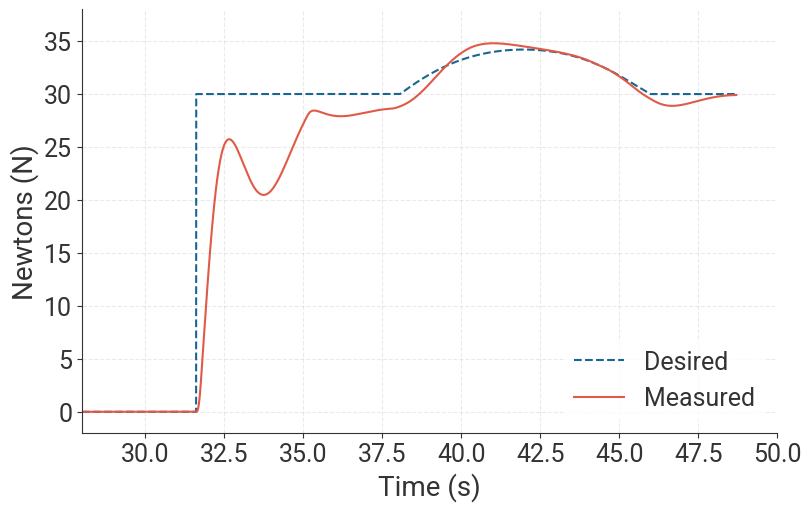

In [6]:
internalForce = PlotTemplate()

x = time
y1 = internalDesiredForce
y2 = internalMeasuredForce

lw = 1.5

with internalForce.figure(
    xlabel="Time (s)", 
    ylabel="Newtons (N)", 
    #title="Demo Palette", 
    save = "InternalForce.png",
    legend=True,
    font_name = "Roboto",
    font_size=24,
    legend_loc="lower right"
    ) as (fig, ax):
        ax.plot(x, y1, label="Desired", linestyle="--", lw=lw,  alpha=0.9)
        ax.plot(x, y2, label="Measured",linestyle="-", lw=lw)
        ax.set_xlim(28, 50)
        ax.set_ylim(-2, 38)
        ax.grid(True, linestyle="--", alpha=0.4, color="#CCCCCC")       


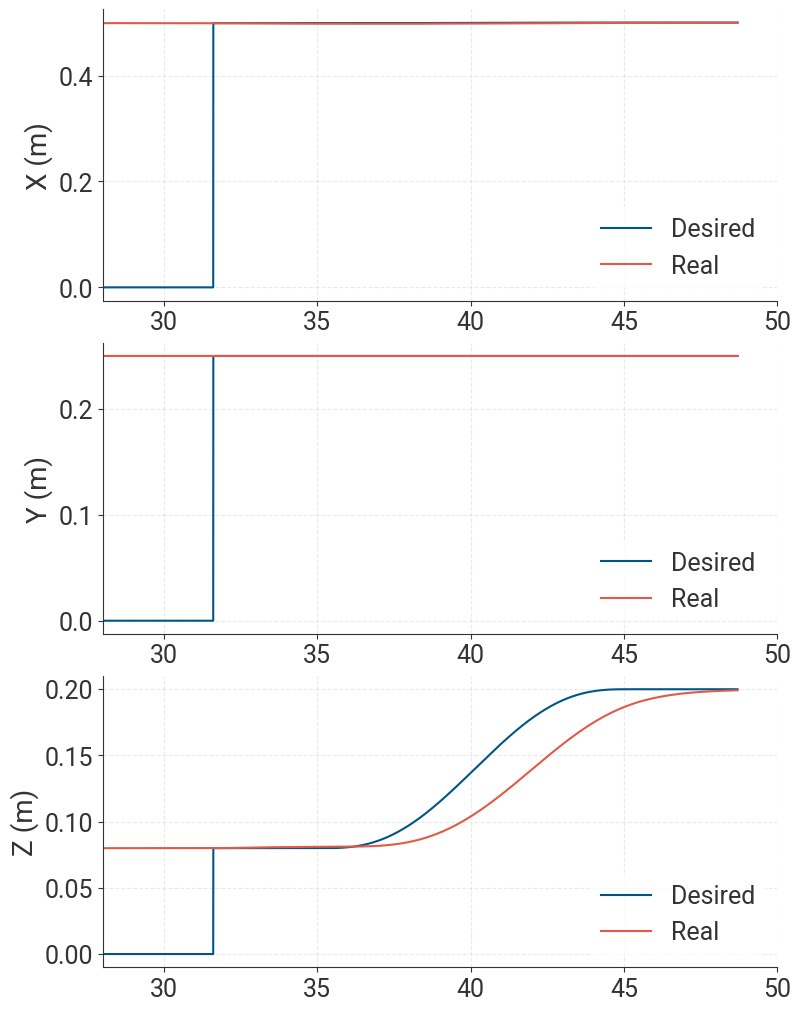

In [7]:
trajectory = PlotTemplate()

x = time
y1Vector = ObjectPlannedTrajectory  # Shape: (3, N)
y2Vector = ObjectRealTrajectory     # Shape: (3, N)

lw = 1.5

with trajectory.figure(
    xlabel="Time (s)", 
    ylabel="Meters (m)", 
    figsize=(8, 10),            # Increased height so 3 subplots aren't squished
    legend=True,
    save = "ObjectTrajecory.png",
    legend_loc="lower right",
    nrows=3,
    font_name="Roboto",
    font_size=24                # Slightly smaller font size works better with 3 subplots
) as (fig, ax):

    # Subplot 1 (Top / X Axis)
    ax[0].plot(x, y1Vector[:,0], label="Desired", lw=lw)
    ax[0].plot(x, y2Vector[:,0], label="Real", lw=lw)
    ax[0].set_xlim(28, 50)
    ax[0].grid(True, linestyle="--", alpha=0.4, color="#CCCCCC")  
    ax[0].set_ylabel("X (m)")

    # Subplot 2 (Middle / Y Axis)
    ax[1].plot(x, y1Vector[:,1], label="Desired", lw=lw)
    ax[1].plot(x, y2Vector[:,1], label="Real", lw=lw)
    ax[1].set_xlim(28, 50)
    ax[1].grid(True, linestyle="--", alpha=0.4, color="#CCCCCC")  
    ax[1].set_ylabel("Y (m)")

    # Subplot 3 (Bottom / Z Axis)
    ax[2].plot(x, y1Vector[:,2], label="Desired", lw=lw)
    ax[2].plot(x, y2Vector[:,2], label="Real", lw=lw)
    ax[2].set_xlim(28, 50)
    ax[2].grid(True, linestyle="--", alpha=0.4, color="#CCCCCC")  
    ax[2].set_ylabel("Z (m)")

# Mechanical power 

required to move or lift a robot, use 

$$P = \tau \times \dot q$$

(48700, 7)
(48700, 7)
(48700,)


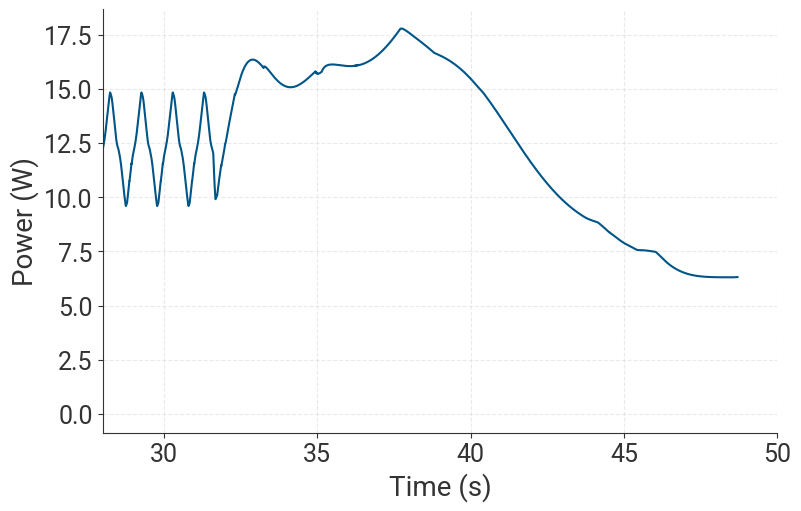

In [8]:
print(RigtArmIn_tau.shape)

print(RigtArmOut_dq.shape)

power = np.sum(RigtArmIn_tau * RigtArmOut_dq, axis=1)
print(power.shape)

Power = PlotTemplate()

x = time
y = np.abs(power)

lw = 1.5

with Power.figure(
    xlabel="Time (s)", 
    ylabel="Power (W)", 
    #title="Demo Palette", 
    legend=True,
    save = "ConsumedPower.png",
    font_name = "Roboto",
    font_size=24,
    legend_loc="best"
    ) as (fig, ax):
        ax.plot(x, y, lw=lw)
        ax.set_xlim(28, 50)
        ax.grid(True, linestyle="--", alpha=0.4, color="#CCCCCC") 
       